In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import anndata

In [9]:
# 定义文件路径
excel_file = "./data/Raman_B.xlsx"

# 读取Excel文件中的所有sheet
data = pd.read_excel(excel_file, sheet_name=None)

# 创建一个字典来存储处理后的数据
processed_data = {}

# 遍历每个sheet，进行数据清洗和预处理
for sheet_name, df in data.items():
    # 直接设置列名为第一行，跳过第一行数据
    df_clean = df.copy()
    df_clean.columns = pd.to_numeric(df_clean.columns, errors='coerce')  # 确保列名为数字
    
    # 筛选波长范围 600 - 1800 (列)
    df_selected = df_clean.loc[:, (df_clean.columns >= 600) & (df_clean.columns <= 1800)]
    
    # 保存处理后的数据
    processed_data[sheet_name] = df_selected

# 合并所有数据到一个AnnData对象
combined_data = []
obs_names = []
var_names = None

for sheet_name, df in processed_data.items():
    # 每个sheet的数据
    combined_data.append(df.values)
    
    # 每行数据的索引名称，添加sheet名区分
    obs_names.extend([f"{sheet_name}_cell{i}" for i in range(df.shape[0])])
    
    # 设置变量名（列名）
    if var_names is None:
        var_names = df.columns.values

# 转换为NumPy数组
X = np.vstack(combined_data)

# 创建AnnData对象
adata = anndata.AnnData(
    X=X,  # 数据矩阵
    obs=pd.DataFrame(index=obs_names),  # 每个样本的名称
    var=pd.DataFrame(index=var_names)  # 每个波长的名称
)

# 显示AnnData对象
adata


g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\anndata\_core\anndata.py:117: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 1415 × 432

In [10]:
adata.X[adata.X < 0] = 0  # 修改原数组
adata.obs['cell_type'] = [name.split('_')[0] for name in obs_names]

In [4]:
adata.write("./data/raman_B.h5ad")

In [5]:
adata.obs_names

Index(['HSC_cell0', 'HSC_cell1', 'HSC_cell2', 'HSC_cell3', 'HSC_cell4',
       'HSC_cell5', 'HSC_cell6', 'HSC_cell7', 'HSC_cell8', 'HSC_cell9',
       ...
       'Naive B_cell315', 'Naive B_cell316', 'Naive B_cell317',
       'Naive B_cell318', 'Naive B_cell319', 'Naive B_cell320',
       'Naive B_cell321', 'Naive B_cell322', 'Naive B_cell323',
       'Naive B_cell324'],
      dtype='object', length=1415)

In [6]:
adata.X

array([[0.00088697, 0.0163035 , 0.0258048 , ..., 0.00109113, 0.00109461,
        0.00107489],
       [0.00291244, 0.0149467 , 0.021224  , ..., 0.00060274, 0.00060223,
        0.00057832],
       [0.00114336, 0.00492756, 0.00688837, ..., 0.00142026, 0.00181803,
        0.00194953],
       ...,
       [0.00833765, 0.012732  , 0.00946591, ..., 0.0021751 , 0.00261014,
        0.00293789],
       [0.0026585 , 0.00491002, 0.00189218, ..., 0.        , 0.        ,
        0.        ],
       [0.00434281, 0.00170368, 0.00203007, ..., 0.        , 0.00010832,
        0.00044538]])

In [6]:
adata_no_scale = adata.copy()
# 为 obs 添加一列细胞类型 (示例：假设不同 sheet 是不同类型的细胞)
adata_no_scale.obs['cell_type'] = [name.split('_')[0] for name in obs_names]

adata_no_scale.layers['raw'] = adata_no_scale.X.copy()
# 数据归一化 (Normalization)
sc.pp.normalize_total(adata_no_scale, target_sum=1e4)
sc.pp.log1p(adata_no_scale)
# PCA 降维
sc.tl.pca(adata_no_scale, svd_solver='arpack')
# UMAP 降维
sc.pp.neighbors(adata_no_scale, n_neighbors=10, n_pcs=20)
sc.tl.umap(adata_no_scale)


g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


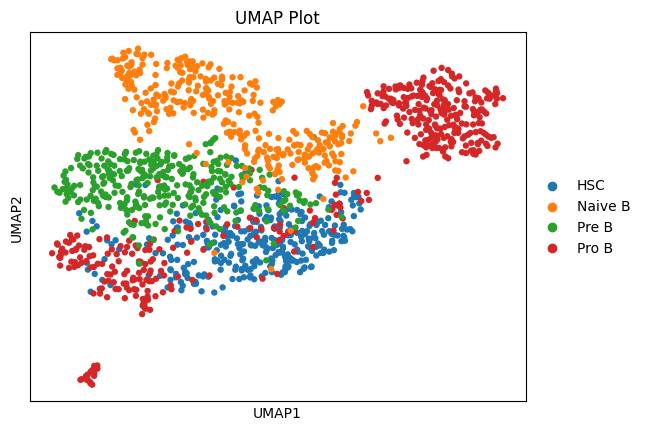

In [7]:
sc.pl.umap(adata_no_scale, color='cell_type', title='UMAP Plot', show=True)

g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


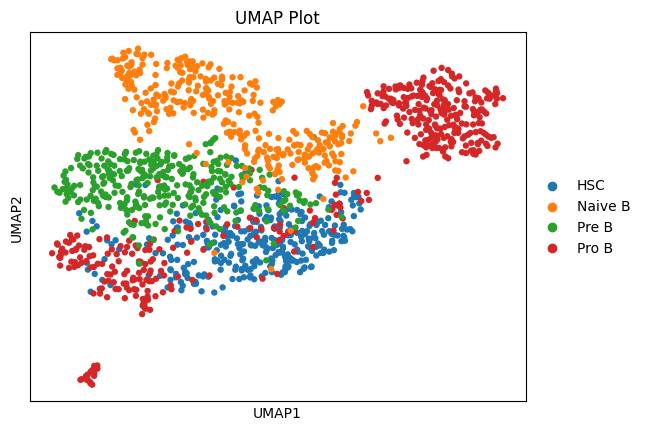

In [36]:
sc.pl.umap(adata_no_scale, color='cell_type', title='UMAP Plot',save="_raman_no_scale.pdf", show=True)

g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


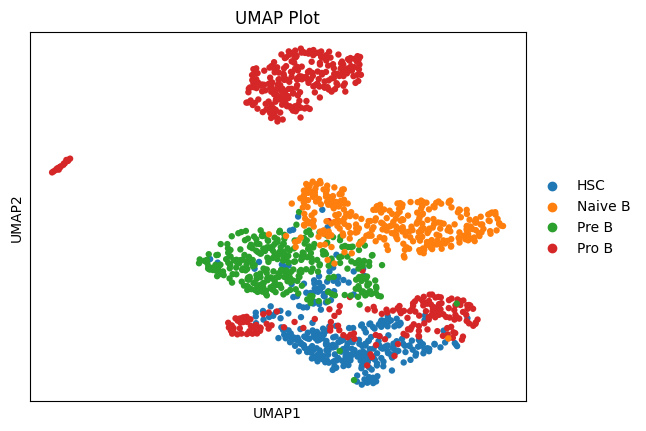

In [ ]:
# 为 obs 添加一列细胞类型 (示例：假设不同 sheet 是不同类型的细胞)
adata.obs['cell_type'] = [name.split('_')[0] for name in obs_names]

adata.layers['raw'] = adata.X.copy()
# 数据归一化 (Normalization)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers['norm'] = adata.X.copy()
# 数据标准化 (scale)
sc.pp.scale(adata)

# PCA 降维
sc.tl.pca(adata, svd_solver='arpack')

# UMAP 降维
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)
sc.tl.umap(adata)
sc.pl.umap(adata, color='cell_type', title='UMAP Plot', show=True)

g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


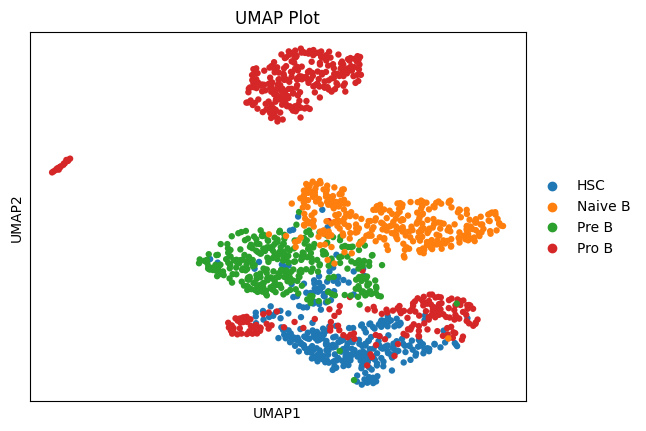

In [37]:
sc.pl.umap(adata, color='cell_type', title='UMAP Plot',save="_raman_scaled.pdf", show=True)

g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_c

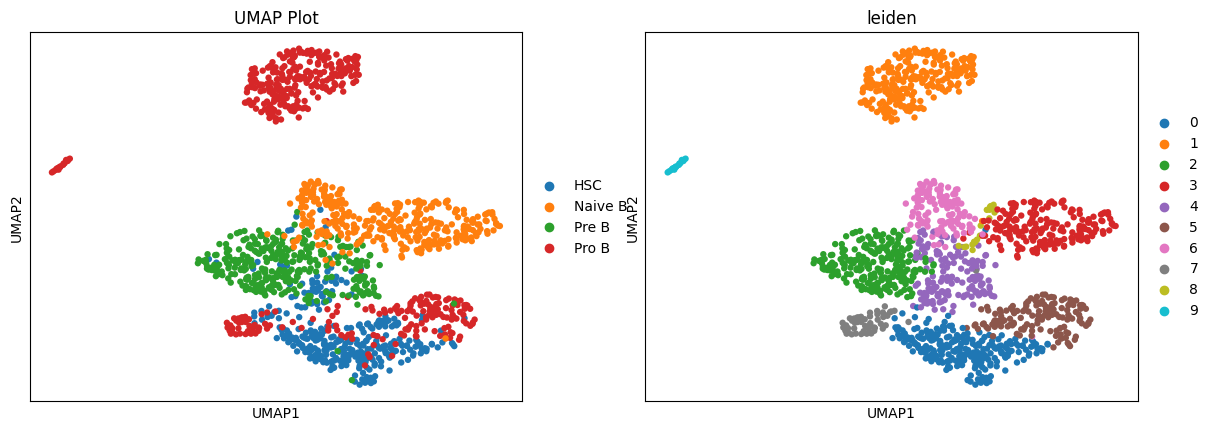

In [33]:
sc.tl.leiden(adata,resolution=0.7)
sc.pl.umap(adata, color=['cell_type','leiden'], title='UMAP Plot', show=True)

In [35]:
sparse_cells = adata[adata.obs['leiden'].isin(['5','7'])].obs_names
[i for i in sparse_cells if 'Pro B' in i]

['Pro B_cell0',
 'Pro B_cell1',
 'Pro B_cell11',
 'Pro B_cell12',
 'Pro B_cell13',
 'Pro B_cell14',
 'Pro B_cell15',
 'Pro B_cell16',
 'Pro B_cell17',
 'Pro B_cell18',
 'Pro B_cell19',
 'Pro B_cell20',
 'Pro B_cell21',
 'Pro B_cell22',
 'Pro B_cell23',
 'Pro B_cell24',
 'Pro B_cell25',
 'Pro B_cell26',
 'Pro B_cell27',
 'Pro B_cell28',
 'Pro B_cell29',
 'Pro B_cell39',
 'Pro B_cell40',
 'Pro B_cell41',
 'Pro B_cell42',
 'Pro B_cell43',
 'Pro B_cell44',
 'Pro B_cell45',
 'Pro B_cell46',
 'Pro B_cell47',
 'Pro B_cell48',
 'Pro B_cell49',
 'Pro B_cell50',
 'Pro B_cell51',
 'Pro B_cell52',
 'Pro B_cell53',
 'Pro B_cell54',
 'Pro B_cell57',
 'Pro B_cell58',
 'Pro B_cell59',
 'Pro B_cell60',
 'Pro B_cell61',
 'Pro B_cell62',
 'Pro B_cell63',
 'Pro B_cell64',
 'Pro B_cell65',
 'Pro B_cell66',
 'Pro B_cell67',
 'Pro B_cell68',
 'Pro B_cell69',
 'Pro B_cell70',
 'Pro B_cell71',
 'Pro B_cell72',
 'Pro B_cell73',
 'Pro B_cell74',
 'Pro B_cell75',
 'Pro B_cell76',
 'Pro B_cell77',
 'Pro B_cell78',

g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1217: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


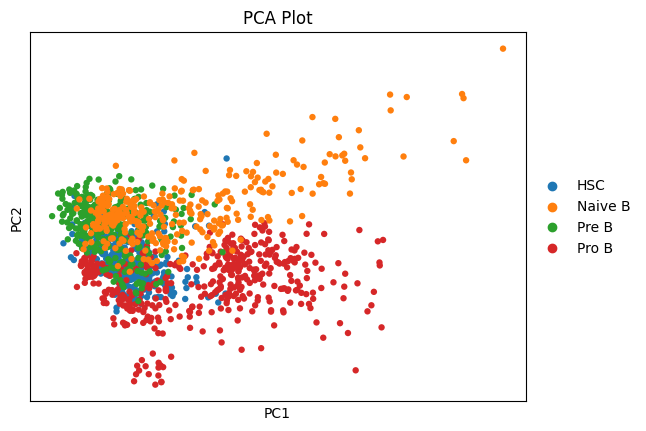

In [20]:
sc.pl.pca(adata, color='cell_type', title='PCA Plot', show=True)

In [33]:
adata.obs.head()

,cell_type
HSC_cell0,HSC
HSC_cell1,HSC
HSC_cell2,HSC
HSC_cell3,HSC
HSC_cell4,HSC


In [27]:
adata.layers['norm']

array([[ 5.54211616e-01,  1.01869830e+01,  1.61237194e+01, ...,
         6.81775249e-01,  6.83949672e-01,  6.71627943e-01],
       [ 1.82993600e+00,  9.39126796e+00,  1.33354032e+01, ...,
         3.78709994e-01,  3.78390181e-01,  3.63365233e-01],
       [ 7.14653463e-01,  3.07995541e+00,  4.30555335e+00, ...,
         8.87728911e-01,  1.13635376e+00,  1.21854741e+00],
       ...,
       [ 5.21791742e+00,  7.96801552e+00,  5.92401176e+00, ...,
         1.36123394e+00,  1.63349325e+00,  1.83860769e+00],
       [ 1.65124908e+00,  3.04971451e+00,  1.17527195e+00, ...,
        -1.32298685e-02, -2.23603411e-02, -6.82766806e-02],
       [ 2.69139406e+00,  1.05583119e+00,  1.25810670e+00, ...,
        -1.11012003e-01,  6.71297627e-02,  2.76014753e-01]])

In [14]:
# 计算细胞类型的差异基因
sc.tl.rank_genes_groups(adata, 'cell_type', method='wilcoxon',layer='norm')


g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


In [15]:
sc.get.rank_genes_groups_df(adata,group=None)

g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,HSC,1682.59,22.538603,10.037706,1.737142e-112,7.504451e-110
1,HSC,1679.97,22.386749,10.385058,5.298437e-111,1.144462e-108
2,HSC,1685.21,22.308052,9.351623,3.086518e-110,4.444586e-108
3,HSC,1677.36,21.982323,10.593682,4.251488e-107,4.591607e-105
4,HSC,1687.82,21.754234,8.652148,6.298827e-105,5.442186e-103
...,...,...,...,...,...,...
1723,Pro B,1345.66,-21.673836,-15.493730,3.622805e-104,7.452628e-103
1724,Pro B,1342.93,-21.684298,-14.100219,2.886351e-104,6.234519e-103
1725,Pro B,1107.08,-22.061867,-8.257305,7.348809e-108,1.763714e-106
1726,Pro B,1101.45,-22.096075,-7.304580,3.447673e-108,8.761146e-107


g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify fut

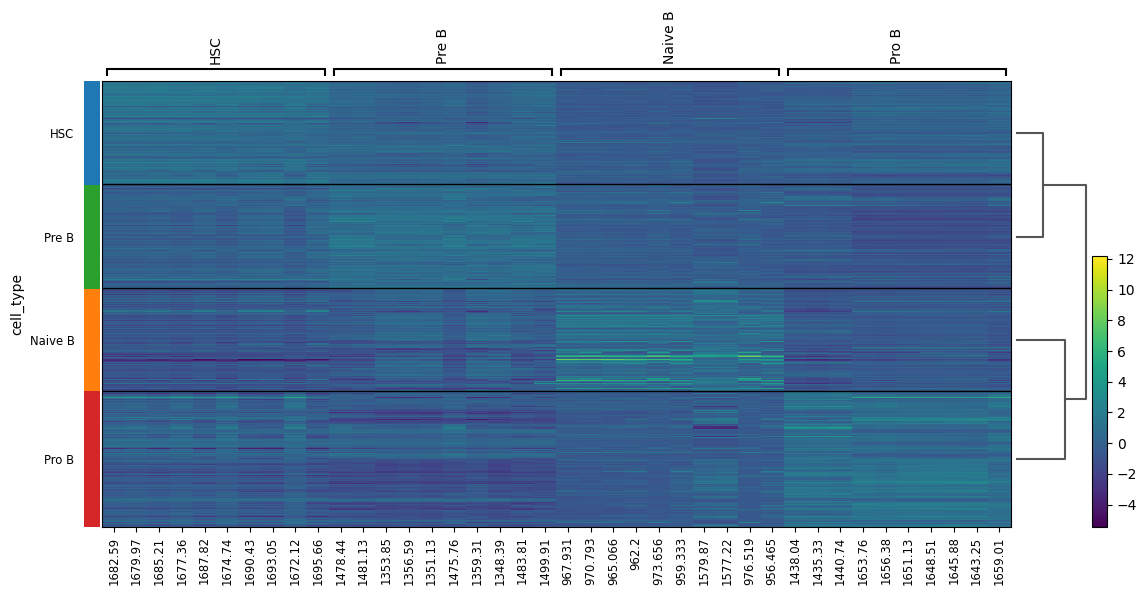

In [16]:
sc.pl.rank_genes_groups_heatmap(adata)

g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify fut

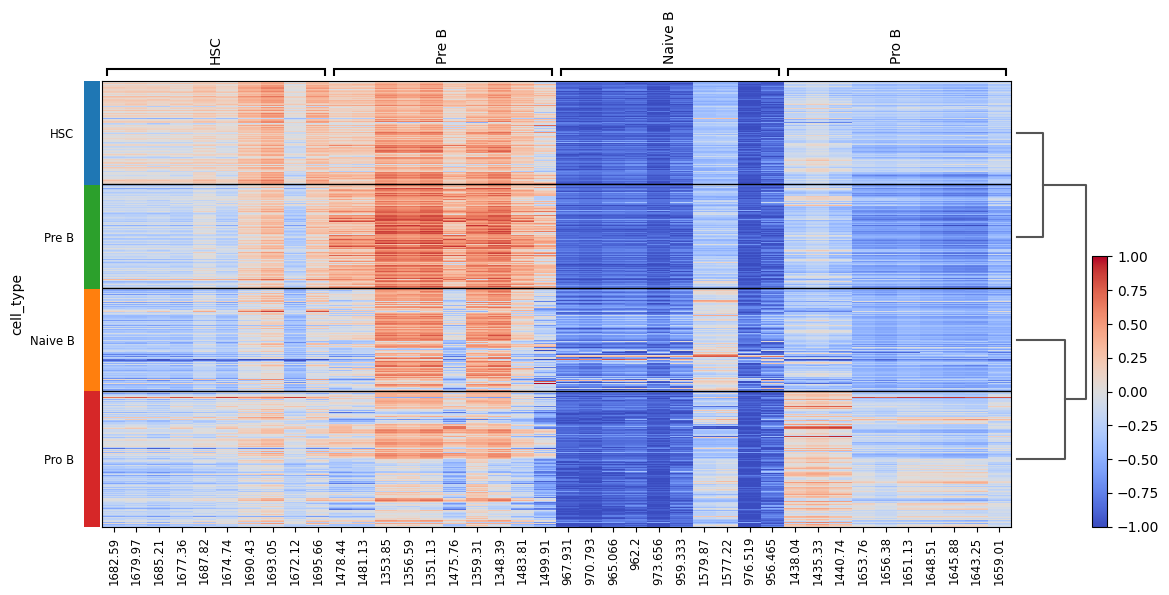

In [30]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 获取热图所需的表达矩阵
heatmap_data = adata.layers['norm']

# 转为矩阵格式（如果是稀疏矩阵需要转为密集格式）
heatmap_matrix = heatmap_data.toarray() if hasattr(heatmap_data, 'toarray') else heatmap_data

# 归一化到 -1 到 1 范围
scaler = MinMaxScaler(feature_range=(-1, 1))
normalized_matrix = scaler.fit_transform(heatmap_matrix)

# 替换原始矩阵以生成热图
adata.layers['normalized'] = normalized_matrix

# 绘制热图
sc.pl.rank_genes_groups_heatmap(adata, layer='normalized', vmin=-1, vmax=1, cmap='coolwarm')


g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d = d.stack(level=1).reset_index()
g:\C_pan_copy_dir\.conda\envs\sc_env\Lib\site-packages\scanpy\get\get.py:66: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify fut

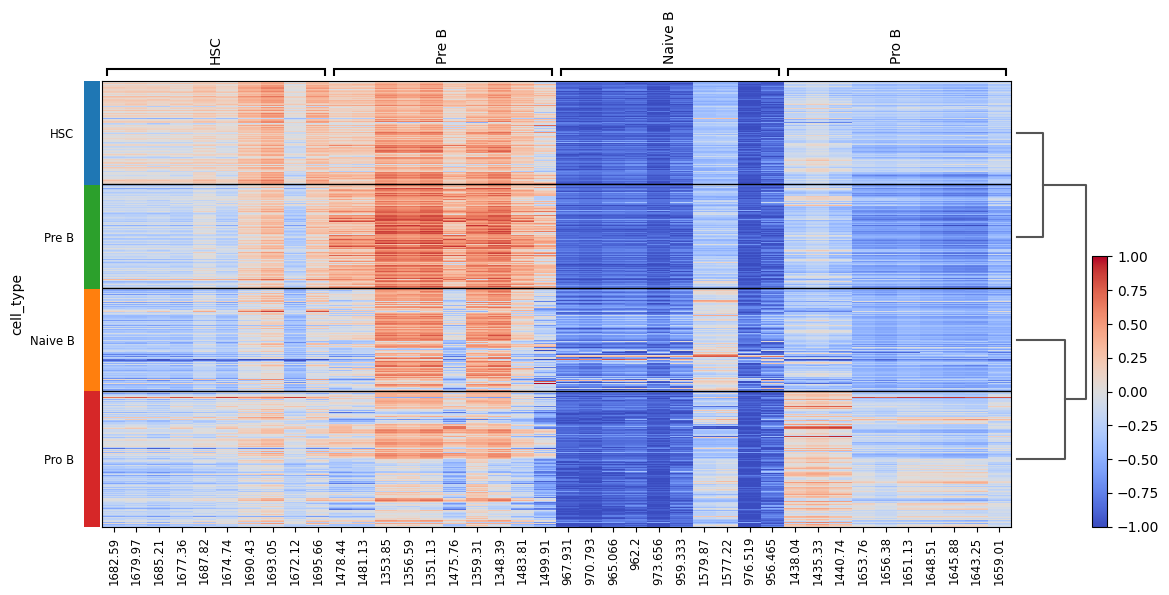

In [38]:
sc.pl.rank_genes_groups_heatmap(adata, layer='normalized', vmin=-1, vmax=1, cmap='coolwarm',save="_raman.pdf")

In [17]:
# 指定cell_type的类别顺序
desired_order = ["HSC", "Pro B", "Pre B", "Naive B"]

# 准备三个数据类型的DataFrame
adata_df_raw = pd.DataFrame(adata.layers['raw'], columns=adata.var.index)
adata_df_raw['cell_type'] = adata.obs['cell_type'].values
adata_df_raw = pd.melt(adata_df_raw, id_vars='cell_type', var_name='Wavenumber', value_name='Intensity')
adata_df_raw['Wavenumber'] = pd.to_numeric(adata_df_raw['Wavenumber'], errors='coerce')
adata_df_raw['Intensity'] = pd.to_numeric(adata_df_raw['Intensity'], errors='coerce')
adata_df_raw['cell_type'] = pd.Categorical(
    adata_df_raw['cell_type'],
    categories=desired_order,
    ordered=True
)

adata_df_norm = pd.DataFrame(adata.layers['norm'], columns=adata.var.index)
adata_df_norm['cell_type'] = adata.obs['cell_type'].values
adata_df_norm = pd.melt(adata_df_norm, id_vars='cell_type', var_name='Wavenumber', value_name='Intensity')
adata_df_norm['Wavenumber'] = pd.to_numeric(adata_df_norm['Wavenumber'], errors='coerce')
adata_df_norm['Intensity'] = pd.to_numeric(adata_df_norm['Intensity'], errors='coerce')
adata_df_norm['cell_type'] = pd.Categorical(
    adata_df_norm['cell_type'],
    categories=desired_order,
    ordered=True
)
adata_df_scaled = pd.DataFrame(adata.X, columns=adata.var.index)
adata_df_scaled['cell_type'] = adata.obs['cell_type'].values
adata_df_scaled = pd.melt(adata_df_scaled, id_vars='cell_type', var_name='Wavenumber', value_name='Intensity')
adata_df_scaled['Wavenumber'] = pd.to_numeric(adata_df_scaled['Wavenumber'], errors='coerce')
adata_df_scaled['Intensity'] = pd.to_numeric(adata_df_scaled['Intensity'], errors='coerce')
adata_df_scaled['cell_type'] = pd.Categorical(
    adata_df_scaled['cell_type'],
    categories=desired_order,
    ordered=True
)

In [39]:
def plot_facet_spectra(data, title, highlight_ranges=None):
    """
    Plot facet spectra with optional highlighted ranges.

    Parameters:
        data (DataFrame): Data to plot, must contain columns 'Wavenumber', 'Intensity', and 'cell_type'.
        title (str): Title of the plot.
        highlight_ranges (list of tuples, optional): List of ranges to highlight, e.g., [(1450, 1650), (1200, 1300)].
    """
    g = sns.FacetGrid(data, col='cell_type', col_wrap=1, height=3, aspect=4)
    # 如果你的seaborn版本为0.12+，可使用errorbar='sd'；否则用ci='sd'
    g.map_dataframe(sns.lineplot, x='Wavenumber', y='Intensity', errorbar='sd')

    if highlight_ranges:
        for ax in g.axes.flat:
            for start, end in highlight_ranges:
                ax.axvspan(start, end, color='red', alpha=0.2)

    g.set_titles(col_template="{col_name}")
    g.set_axis_labels('Wavenumber (cm^-1)', 'Intensity')
    g.set(xlim=(600, 1800), xticks=np.arange(600, 1801, 100))
    plt.subplots_adjust(top=0.9)
    g.fig.suptitle(title, y=1)

    # Save the figure to a PDF file
    output_path = f"./figures/{title.replace(' ', '_')}.pdf"
    plt.savefig(output_path, format='pdf')
    plt.show()

# 示例调用
# highlight_ranges = [(1450, 1650), (1200, 1300)]
# plot_facet_spectra(adata_df_raw, "Raw Spectra", highlight_ranges=highlight_ranges)


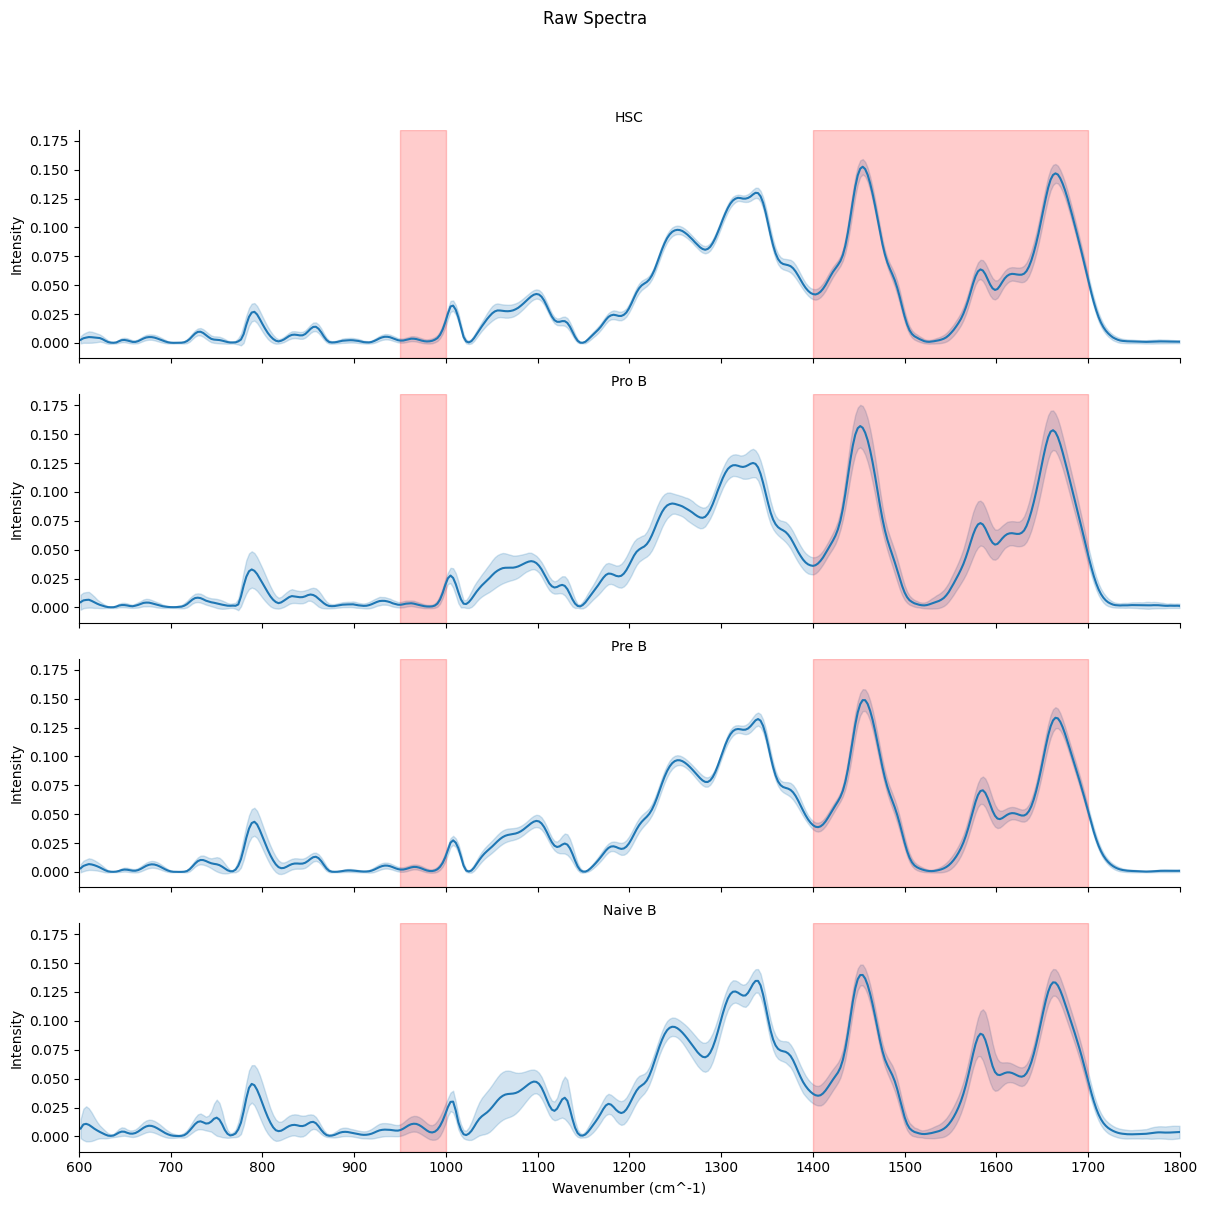

In [40]:
# 示例调用
highlight_ranges = [(950, 1000),(1400, 1700)]
plot_facet_spectra(adata_df_raw, "Raw Spectra", highlight_ranges=highlight_ranges)

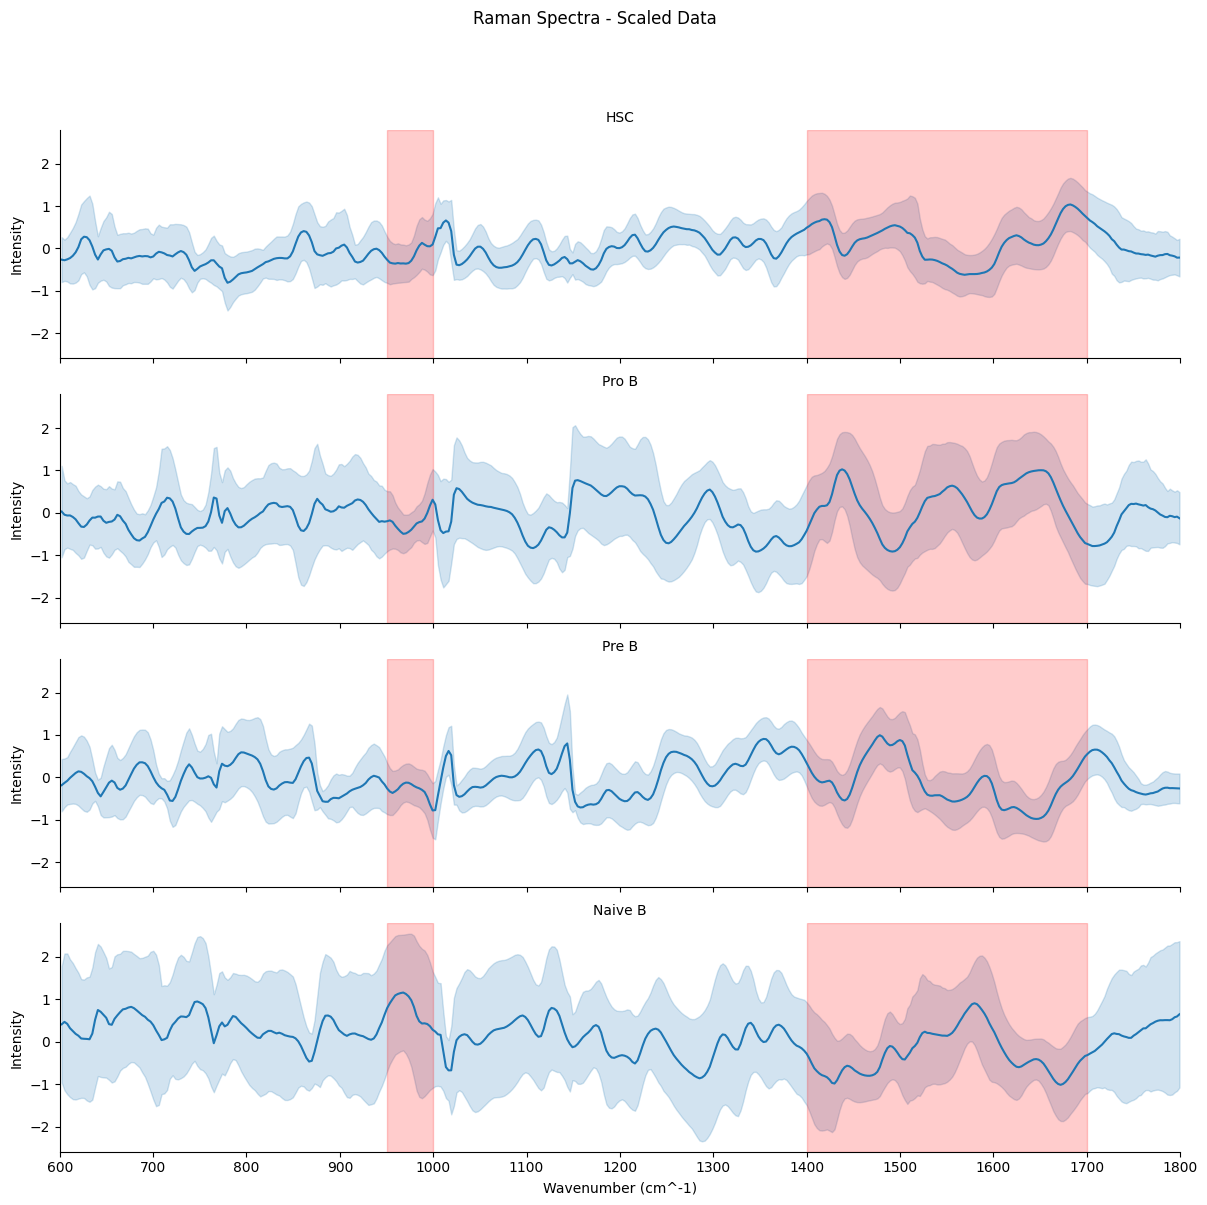

In [41]:
# 示例调用
highlight_ranges = [(950, 1000),(1400, 1700)]
plot_facet_spectra(adata_df_scaled, 'Raman Spectra - Scaled Data', highlight_ranges=highlight_ranges)


In [28]:
adata_df_norm

,cell_type,Wavenumber,Intensity
0,HSC,602.022,0.554212
1,HSC,602.022,1.829936
2,HSC,602.022,0.714653
3,HSC,602.022,0.613178
4,HSC,602.022,3.891197
...,...,...,...
611275,Naive B,1799.400,2.141249
611276,Naive B,1799.400,1.115570
611277,Naive B,1799.400,1.838608
611278,Naive B,1799.400,-0.068277


In [22]:
adata_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 611280 entries, 0 to 611279
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   cell_type   611280 non-null  category
 1   Wavenumber  611280 non-null  float64 
 2   Intensity   611280 non-null  float64 
dtypes: category(1), float64(2)
memory usage: 9.9 MB


In [53]:
adata_df_raw.dtypes

cell_type     category
Wavenumber     float64
Intensity      float64
dtype: object

In [55]:
print(adata_df_raw['Wavenumber'].min(), adata_df_raw['Wavenumber'].max())


602.022 1799.4


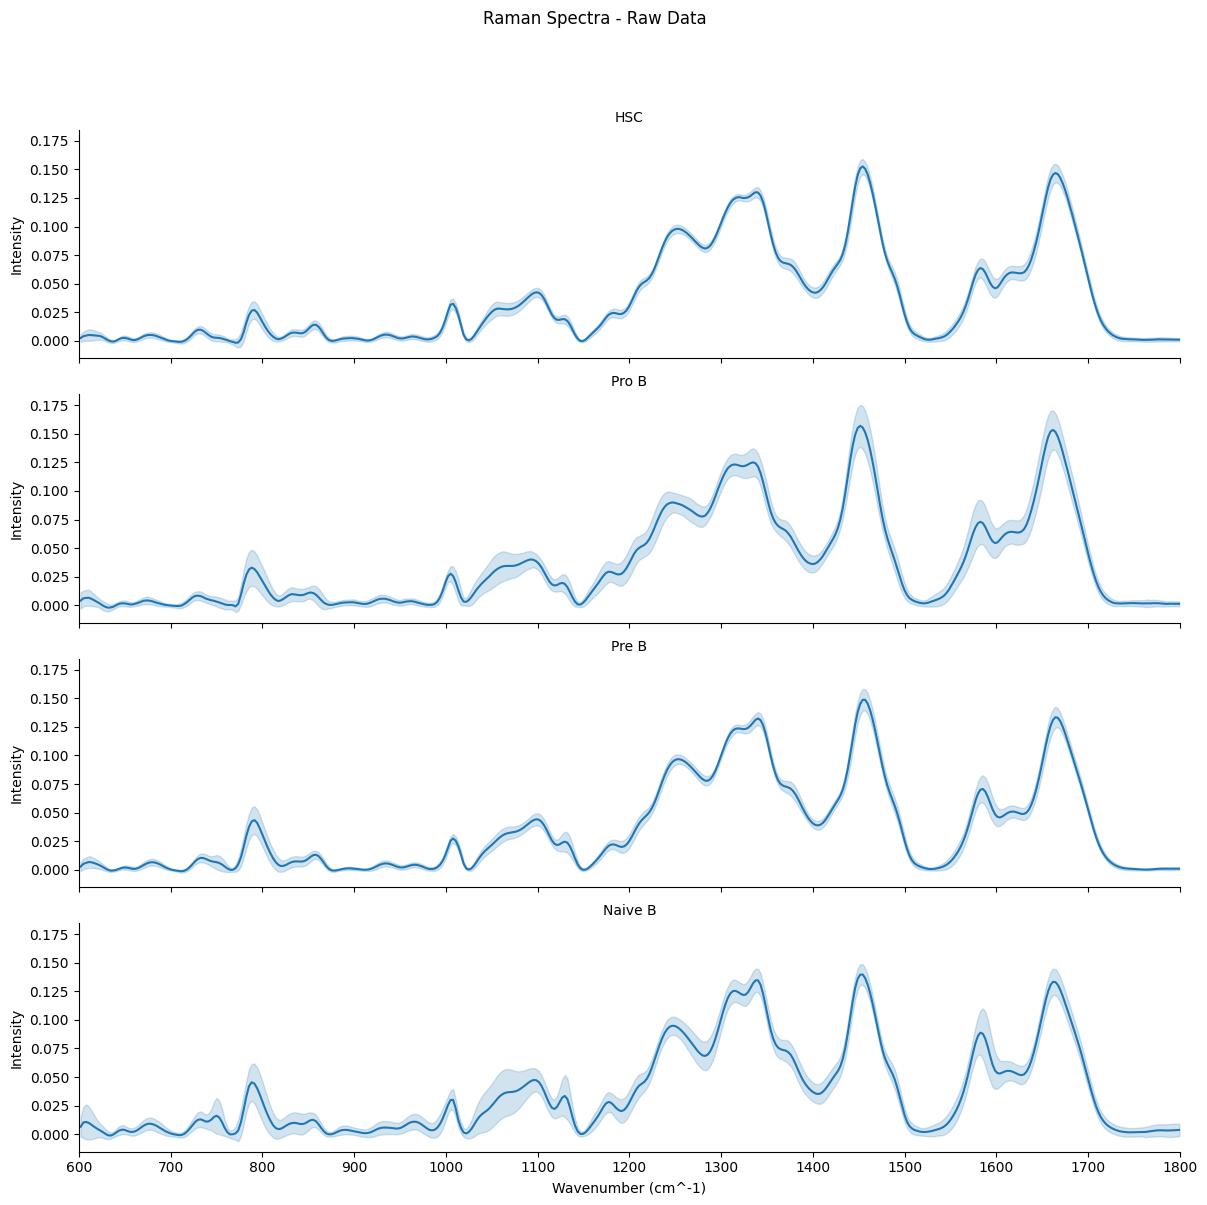

In [33]:
# 分别绘制三个数据的分面光谱图
plot_facet_spectra(adata_df_raw, 'Raman Spectra - Raw Data')

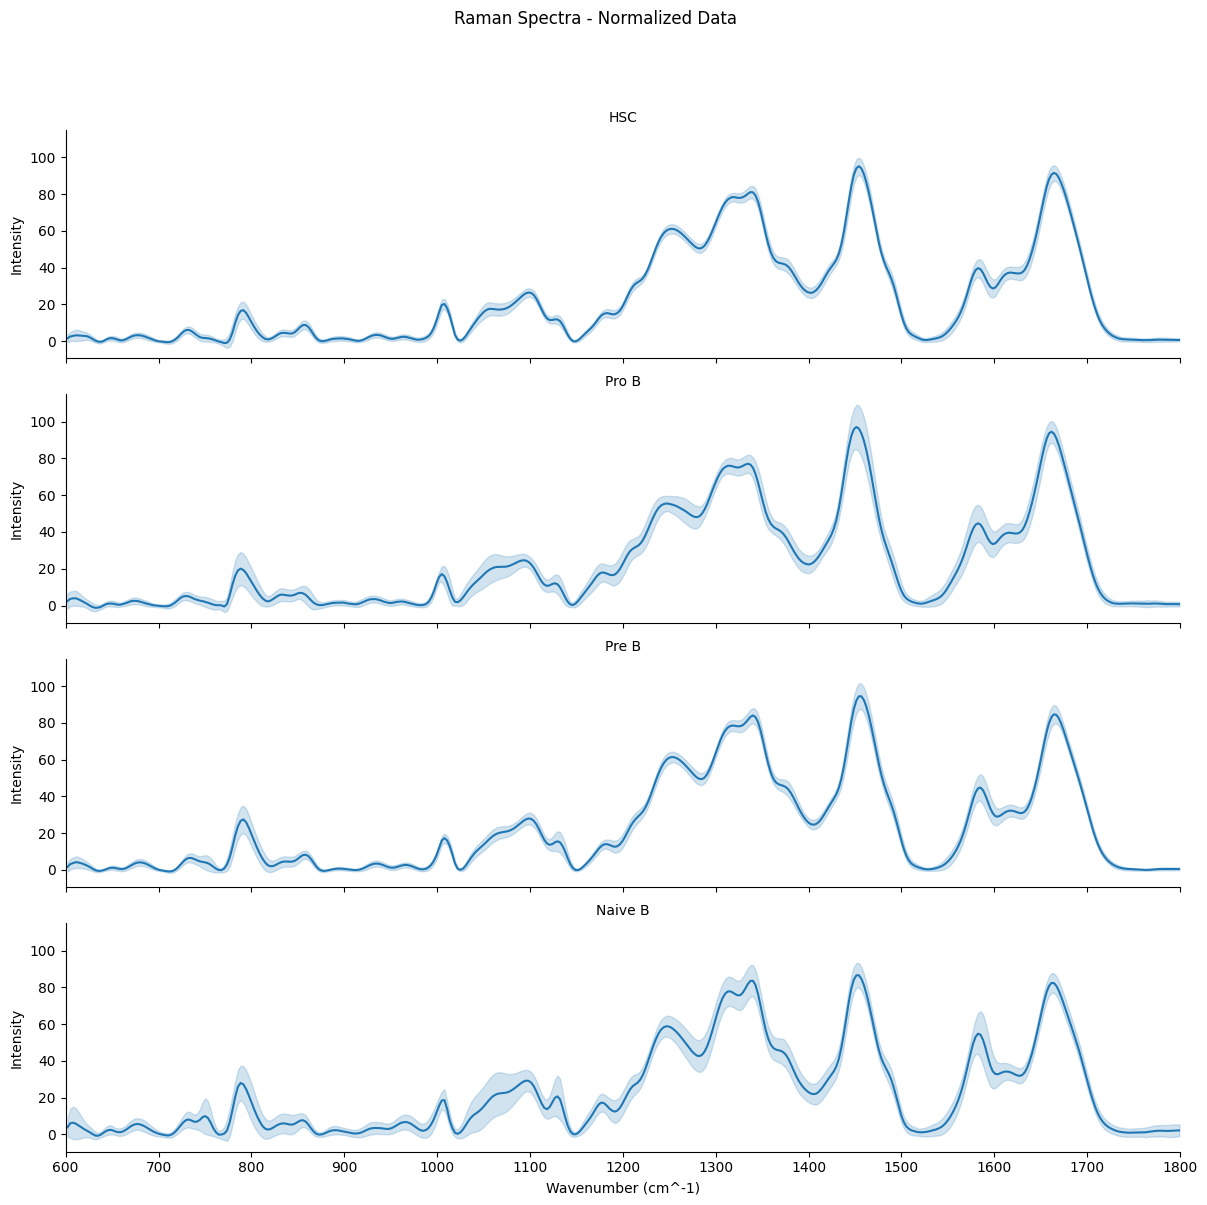

In [34]:
plot_facet_spectra(adata_df_norm, 'Raman Spectra - Normalized Data')

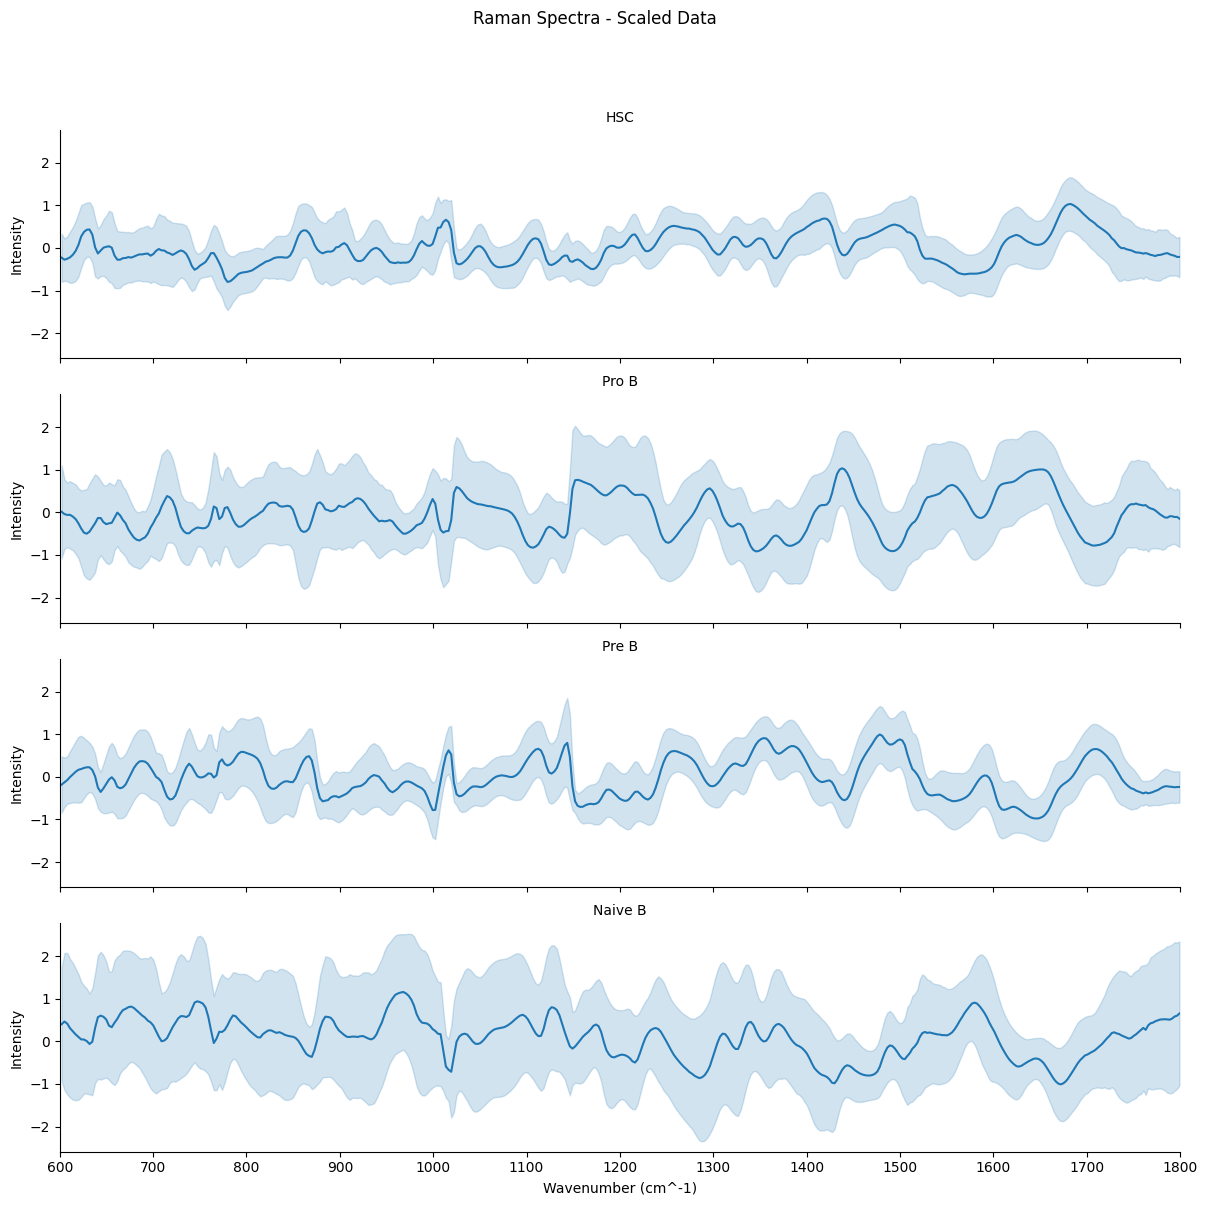

In [35]:
plot_facet_spectra(adata_df_scaled, 'Raman Spectra - Scaled Data')

In [67]:
df_stats = adata_df_raw.groupby('cell_type').agg(
    mean_intensity=('Intensity', 'mean'),
    std_intensity=('Intensity', 'std'),
    count=('Intensity', 'count')
)

# 增加变异系数列
df_stats['cv_intensity'] = df_stats['std_intensity'] / df_stats['mean_intensity']
print(df_stats)


           mean_intensity  std_intensity   count  cv_intensity
cell_type                                                     
HSC              0.037145       0.042175  142128      1.135424
Pro B            0.037550       0.042872  186192      1.141736
Pre B            0.036457       0.040624  142560      1.114282
Naive B          0.037406       0.040121  140400      1.072606


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14984\1808997886.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_stats = adata_df_raw.groupby('cell_type').agg(


C:\Users\Administrator\AppData\Local\Temp\ipykernel_14984\4217219985.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot = adata_df_raw.pivot_table(index='cell_type', columns='Wavenumber', values='Intensity', aggfunc='mean')


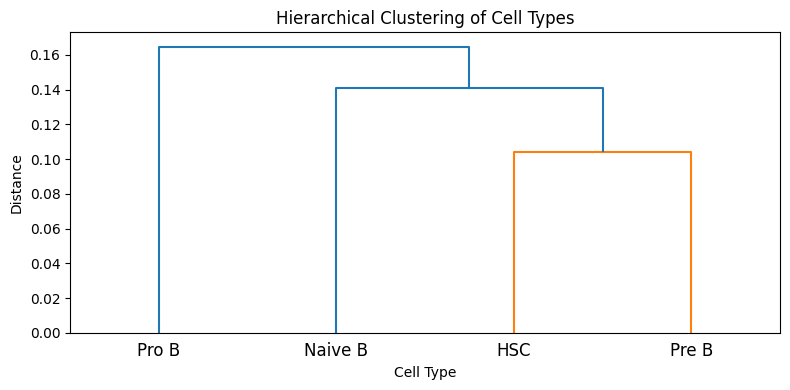

In [68]:
from scipy.cluster.hierarchy import linkage, dendrogram

# 假设 adata_df_raw 已包含 cell_type, Wavenumber, Intensity 三列
# 建立数据透视表：行为cell_type，列为Wavenumber，值为Intensity平均值
df_pivot = adata_df_raw.pivot_table(index='cell_type', columns='Wavenumber', values='Intensity', aggfunc='mean')

# 使用层次聚类 (method='ward' 以最小化组内平方和距离为聚类准则)
Z = linkage(df_pivot, method='ward')

# 绘制树状图
plt.figure(figsize=(8, 4))
dendrogram(Z, labels=df_pivot.index.tolist())
plt.title('Hierarchical Clustering of Cell Types')
plt.xlabel('Cell Type')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


In [69]:
adata

AnnData object with n_obs × n_vars = 1415 × 432
    obs: 'cell_type'
    var: 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap', 'cell_type_colors', 'rank_genes_groups', 'dendrogram_cell_type'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'raw', 'norm'
    obsp: 'distances', 'connectivities'

关于LDA的概念与原理

LDA（Linear Discriminant Analysis）线性判别分析是一种用于分类和降维的线性方法，它的主要目标是找到一组投影方向，使得在这些新坐标轴上投影后的数据能够尽可能地区分不同的已知类别（类标签）。简而言之，LDA寻找能最大化类间差异（between-class variance）并最小化类内差异（within-class variance）的线性投影方向。

为什么LDA是监督学习？
LDA 需要已知的类别标签（如HSC, ProB, PreB, Naive B）来指导它寻找最佳投影方向。通过利用这些标签，LDA尝试在新的子空间中让不同类别的样本尽可能分开。这与PCA形成对比：

**PCA（Principal Component Analysis）**是无监督的方法，它只考虑数据的整体方差结构，而不利用任何类别信息。它寻找最大方差方向，这些方向并不一定与类别区分相关。
LDA是有监督的方法，因为它明确利用了类别标签去最大化类间距离、最小化类内距离，从而得到对分类最有利的降维结果。
为什么LDA也能画出像PCA那样的散点图？
LDA和PCA都是线性降维方法，其核心思想都是将高维数据投影到低维子空间上，因此在视觉上都会将原数据以散点图的形式呈现在2D或3D的低维空间中。

PCA寻找的是数据在无类别信息条件下的最大方差方向，将数据投影后可以画出散点图。
LDA利用类标签寻找使类别分离度最大的方向，将数据投影后同样可以得到低维坐标，从而绘制散点图。
因此，从形式上看，LDA降维后的结果也可以用散点图呈现，就像PCA的结果一样，只不过LDA的坐标轴是带有类别信息的“判别轴”(Linear Discriminants)，而PCA的坐标轴是最大方差方向（Principal Components）。

In [48]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 提取数据和标签
X = adata.X               # shape: (n_samples, n_features)
y = adata.obs['cell_type'].values

# LDA降维到3维
lda = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(X, y)  # (n_samples, 3)

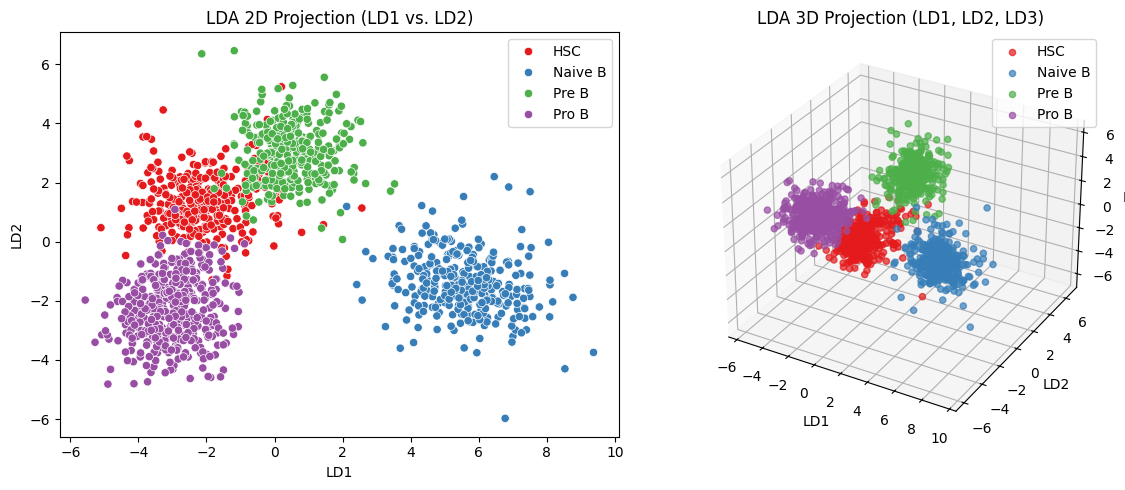

In [71]:
# 绘制2D散点图（前两个LD分量）
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=y, palette='Set1')
plt.title("LDA 2D Projection (LD1 vs. LD2)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()

# 绘制3D散点图（前三个LD分量）
ax = plt.subplot(1, 2, 2, projection='3d')

# 为了更好区分每一类，在3D图上分组绘制
classes = np.unique(y)
colors = sns.color_palette('Set1', n_colors=len(classes))

for c, color in zip(classes, colors):
    mask = (y == c)
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], X_lda[mask, 2],
               label=c, color=color, alpha=0.7)

ax.set_title("LDA 3D Projection (LD1, LD2, LD3)")
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14984\1533874508.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Weight', y='Feature', palette='viridis')


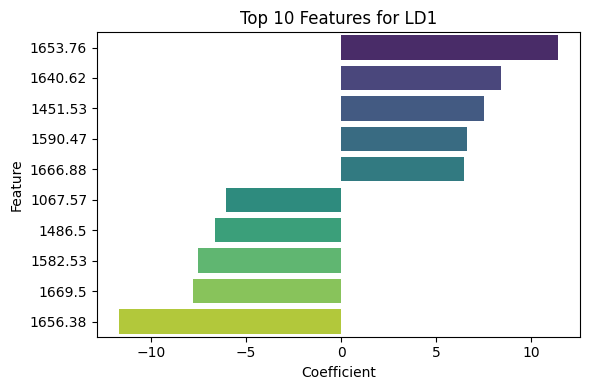

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14984\1533874508.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Weight', y='Feature', palette='viridis')


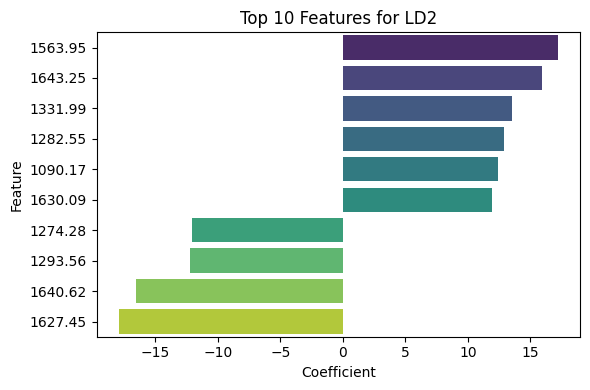

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14984\1533874508.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Weight', y='Feature', palette='viridis')


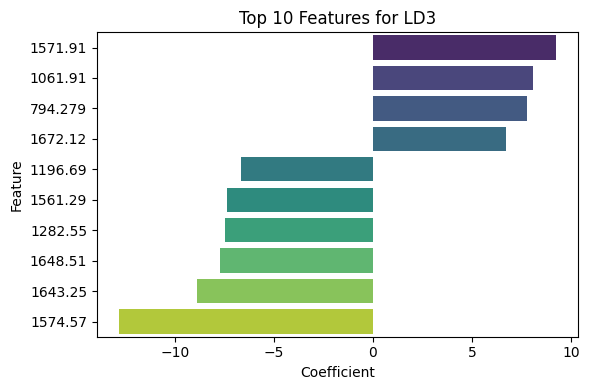

In [73]:
feature_names = adata.var.index  # 特征名称（例如波数点）

# 获取三个LD的系数
ld1_coefs = lda.coef_[0, :]
ld2_coefs = lda.coef_[1, :]
ld3_coefs = lda.coef_[2, :]

def plot_top_features(coefs, feature_names, ld_name, top_n=10):
    # 按绝对值排序，取前top_n
    idx = np.argsort(np.abs(coefs))[::-1][:top_n]
    top_features = feature_names[idx]
    top_weights = coefs[idx]

    # 组合成DataFrame便于绘制
    df_plot = pd.DataFrame({
        'Feature': top_features,
        'Weight': top_weights
    })
    df_plot = df_plot.sort_values('Weight', ascending=False)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=df_plot, x='Weight', y='Feature', palette='viridis')
    plt.title(f"Top {top_n} Features for {ld_name}")
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# 绘制LD1的top10特征
plot_top_features(ld1_coefs, feature_names, "LD1", top_n=10)

# 绘制LD2的top10特征
plot_top_features(ld2_coefs, feature_names, "LD2", top_n=10)

# 绘制LD3的top10特征
plot_top_features(ld3_coefs, feature_names, "LD3", top_n=10)


In [49]:
import numpy as np

scalings = lda.scalings_  # shape: (n_features, n_components)
n_features, n_components = scalings.shape
print("lda.scalings_ shape:", scalings.shape)

top_k = 10  # 想要查看前10名

for dim in range(n_components):
    loadings = scalings[:, dim]  # 第dim列 = 对应 LD(dim+1) 的投影系数，shape: (n_features,)
    # 根据绝对值从大到小排序
    idx_sorted = np.argsort(np.abs(loadings))[::-1]
    top_indices = idx_sorted[:top_k]
    
    # 这几个最相关特征的系数
    top_loadings = loadings[top_indices]
    
    print(f"\n=== LD{dim+1} ===")
    print("Top 10 feature indices:", top_indices)
    print("Coefficients:", top_loadings)


lda.scalings_ shape: (432, 3)

=== LD1 ===
Top 10 feature indices: [341 365 370 346 153 299 168 371 353 295]
Coefficients: [ 3.2329368  -3.01629678 -2.63218918  2.2489055   2.17610855 -2.17261689
  2.13490844  2.13028467 -2.11854361  2.09406749]

=== LD2 ===
Top 10 feature indices: [345 340 382 344 373 237 339 349 346 371]
Coefficients: [-3.94672024 -3.11499617  2.78862052  2.4588535  -2.39004022 -2.38836616
  2.33065772  2.32165639  2.24243816 -2.21084983]

=== LD3 ===
Top 10 feature indices: [375 376 381 380 218 155 351 209 336 338]
Coefficients: [-2.50332864  2.4660847   2.21086913 -2.13272095 -2.01338511 -1.79344476
 -1.77035168  1.76010375 -1.70905124  1.6858056 ]


In [53]:
# 假设 feature_names[i] 表示第 i 个特征的名字/波数
feature_names = adata.var_names.to_list()
for dim in range(n_components):
    loadings = scalings[:, dim]
    idx_sorted = np.argsort(np.abs(loadings))[::-1]
    top_indices = idx_sorted[:top_k]
    
    # 打印 Top10 特征名以及对应系数
    print(f"\n=== LD{dim+1} ===")
    for rank, i_feature in enumerate(top_indices):
        print(f"{rank+1}. Feature index: {i_feature} | "
              f"Name: {feature_names[i_feature]} | "
              f"Coefficient: {loadings[i_feature]:.4f}")



=== LD1 ===
1. Feature index: 341 | Name: 1563.95 | Coefficient: 3.2329
2. Feature index: 365 | Name: 1627.45 | Coefficient: -3.0163
3. Feature index: 370 | Name: 1640.62 | Coefficient: -2.6322
4. Feature index: 346 | Name: 1577.22 | Coefficient: 2.2489
5. Feature index: 153 | Name: 1047.74 | Coefficient: 2.1761
6. Feature index: 299 | Name: 1451.53 | Coefficient: -2.1726
7. Feature index: 168 | Name: 1090.17 | Coefficient: 2.1349
8. Feature index: 371 | Name: 1643.25 | Coefficient: 2.1303
9. Feature index: 353 | Name: 1595.77 | Coefficient: -2.1185
10. Feature index: 295 | Name: 1440.74 | Coefficient: 2.0941

=== LD2 ===
1. Feature index: 345 | Name: 1574.57 | Coefficient: -3.9467
2. Feature index: 340 | Name: 1561.29 | Coefficient: -3.1150
3. Feature index: 382 | Name: 1672.12 | Coefficient: 2.7886
4. Feature index: 344 | Name: 1571.91 | Coefficient: 2.4589
5. Feature index: 373 | Name: 1648.51 | Coefficient: -2.3900
6. Feature index: 237 | Name: 1282.55 | Coefficient: -2.3884
7. Fe

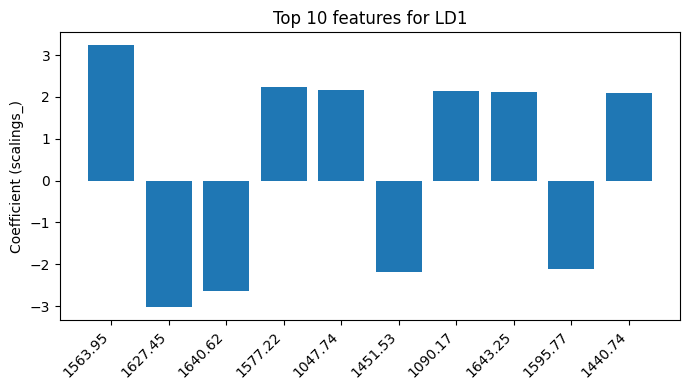

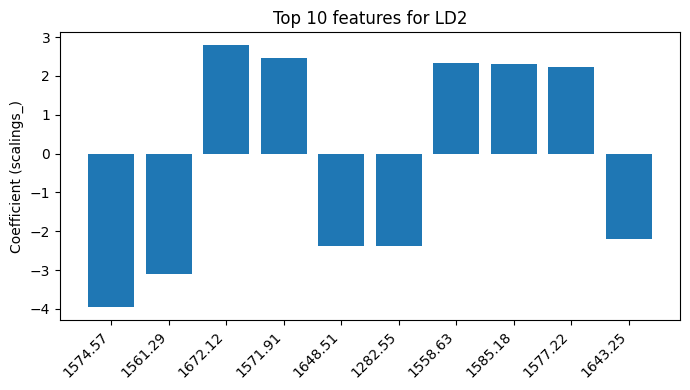

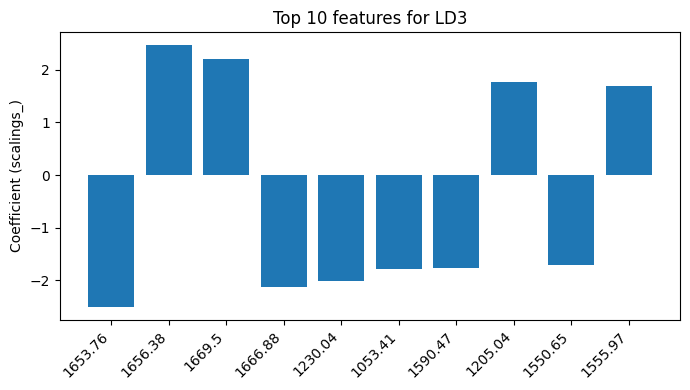

In [54]:
import matplotlib.pyplot as plt

# 如果没有明确的特征名，可以用字符串化的索引
# feature_names = [f"feature_{i}" for i in range(n_features)]

top_k = 10

for dim in range(n_components):
    loadings = scalings[:, dim]
    idx_sorted = np.argsort(np.abs(loadings))[::-1]
    top_indices = idx_sorted[:top_k]
    
    top_loadings = loadings[top_indices]
    top_labels = [feature_names[i] for i in top_indices]
    
    # 为了让正负值更直观，可以不取绝对值；如果你只关心重要性大小，可以画绝对值
    plt.figure(figsize=(7, 4))
    
    # 绘制条形图
    plt.bar(range(top_k), top_loadings, align='center')
    
    # X轴设置为特征名，并稍微倾斜一点
    plt.xticks(range(top_k), top_labels, rotation=45, ha='right')
    
    plt.ylabel("Coefficient (scalings_)")
    plt.title(f"Top 10 features for LD{dim+1}")
    plt.tight_layout()
    plt.show()


在LDA中，判别轴（LD）是特征的线性组合，即：

\[
\text{LD}_k = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n
\]

其中 \( w_i \) 为特征 \( x_i \) 在第 \( k \) 个判别轴上的权重（系数）。权重的正负号有以下含义：

1. **正权重**：当该特征的值越大时，会使得投影到该LD轴上的坐标值相对更大，样本在该LD轴方向上偏向正方向。例如，如果LD1是用于区分两类细胞类型，那么对权重为正的特征而言，当该特征值增大，样本更倾向于被投射在LD1的正侧，从而更“接近”或“有利于”那些在LD1正侧分布的类别。

2. **负权重**：当该特征的值越大时，会使得投影到该LD轴上的坐标值更加偏向负方向。也就是说，这些特征值的增大将样本推向LD轴的负侧，更有助于将该样本区分为在负侧聚集的类别。

简单来说，权重的正负号表明了该特征在该判别轴上对分类方向的影响趋势：  
- 正值特征推动数据点沿判别轴正方向移动，有利于区分朝正方向分布的类。  
- 负值特征推动数据点沿判别轴负方向移动，有利于区分朝负方向分布的类。

最终，这些特征的正负权重配合各类别在LD轴上的分布情况，可以帮助我们理解哪些特征倾向于将样本“拉向”特定的类别方向。

In [36]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split

# 假设 X, y 分别是你的光谱数据和标签
X = adata.X
y = adata.obs['cell_type'].values

# 1) 拆分训练集与测试集 (模拟文献中的1/6排除法，比例自行调整)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/6, stratify=y, random_state=42
)

# 2) PCA 先对训练集做 fit，然后 transform 训练集和测试集
pca = PCA(n_components=0.98)  
# n_components=0.98 表示自动选取能解释98%方差的主成分数量
# 也可用整数k来手动指定保留k个主成分

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 3) 在PCA之后的空间上，进行LDA
lda = LinearDiscriminantAnalysis(n_components=3)
X_train_lda = lda.fit_transform(X_train_pca, y_train)
X_test_lda = lda.transform(X_test_pca)

# 4) 用LDA自带的分类器对测试集进行预测
y_pred = lda.predict(X_test_pca)

# 5) 计算分类准确率
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)
print("PC-LDA 测试集准确率: {:.2f}%".format(acc * 100))


PC-LDA 测试集准确率: 94.92%


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mpl_toolkits.mplot3d import Axes3D  # 用于3D绘图

# 假设 X, y 已准备好
# X.shape = (n_samples, n_features)
# y.shape = (n_samples, )

# 1) PCA：保留能解释 98% 方差的主成分
pca = PCA(n_components=0.98)
X_pca = pca.fit_transform(X)

print(f"PCA后维度: {X_pca.shape[1]} (保留98%累积方差)")

# 2) LDA：在 PCA 后的空间再做线性判别分析
lda = LinearDiscriminantAnalysis(n_components=3) 
X_lda = lda.fit_transform(X_pca, y)  # shape: (n_samples, 3)
print("LDA后维度:", X_lda.shape[1])


PCA后维度: 97 (保留98%累积方差)
LDA后维度: 3


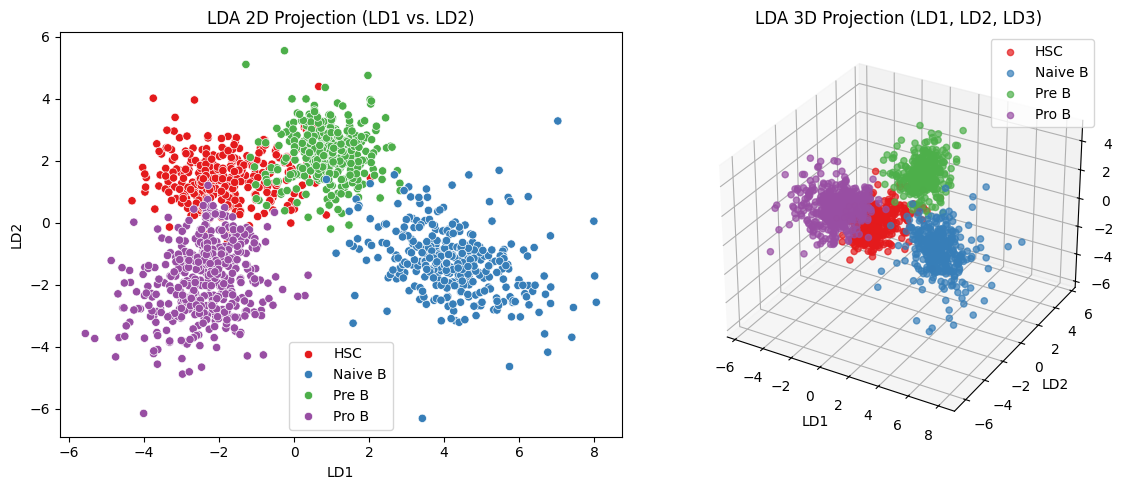

In [41]:
# 绘制2D散点图（前两个LD分量）
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_lda[:,0], y=X_lda[:,1], hue=y, palette='Set1')
plt.title("LDA 2D Projection (LD1 vs. LD2)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()

# 绘制3D散点图（前三个LD分量）
ax = plt.subplot(1, 2, 2, projection='3d')

# 为了更好区分每一类，在3D图上分组绘制
classes = np.unique(y)
colors = sns.color_palette('Set1', n_colors=len(classes))

for c, color in zip(classes, colors):
    mask = (y == c)
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], X_lda[mask, 2],
               label=c, color=color, alpha=0.7)

ax.set_title("LDA 3D Projection (LD1, LD2, LD3)")
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.set_zlabel("LD3")
ax.legend()

plt.tight_layout()
plt.show()

In [56]:
lda.scalings_.shape

(432, 3)

In [58]:
lda.coef_.shape

(4, 432)